# Quration Resource Estimation with Multiple Circuits

This tutorial shows how to analyze a parameterized circuit across different parameter values with [quration](https://github.com/quration/quration), so you can see how the FTQC cost responds as you vary a parameter. Here you take one Quantum Phase Estimation (QPE) circuit, vary the number of phase-readout qubits (3, 4, 5), and compare the three profiles in the visualizer.

For a detailed explanation of each step, see the [basic quration tutorial](basic_resource_estimation.ipynb), which covers a single circuit and documents every metric.


In [ ]:
# If quri-parts (with the qret extra) and quri-algo are not installed, install them with the following commands:
# %pip install "quri-parts[qret]"
# %pip install quri-algo


## Write a QPE Circuit with Qsub


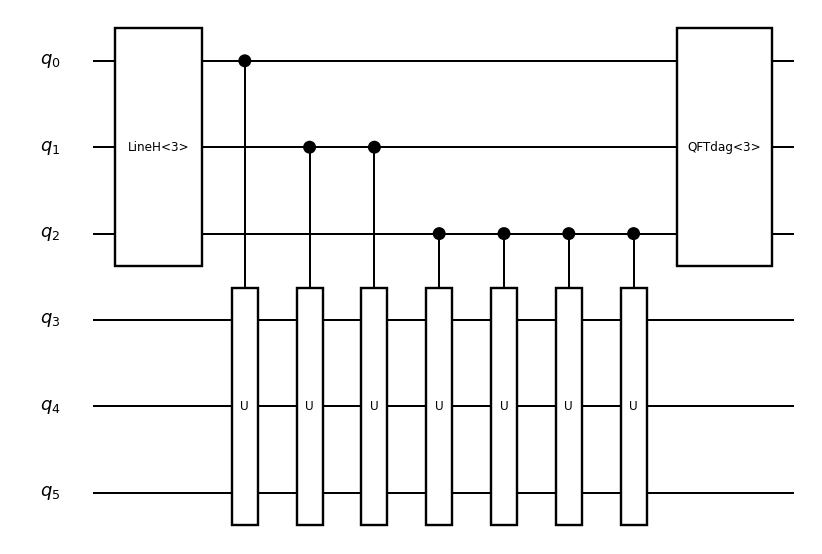

In [ ]:
from quri_parts.qsub.lib import std
from quri_algo.circuit_lib.qpe import QPE
from quri_parts.qsub.opsub import UnitarySubDef, opsub
from quri_parts.qsub.sub import SubBuilder
from quri_parts.qsub.visualize import draw

class _U(UnitarySubDef):
    name = "U"
    qubit_count = 3

    def sub(self, builder: SubBuilder) -> None:
        for i, q in enumerate(builder.qubits):
            builder.add_op(std.RX(0.1 * (i + 1)), (q,))


U, _ = opsub(_U)

qpe_u_ops = [QPE(i, U) for i in range(3, 6)]
draw(qpe_u_ops[0])

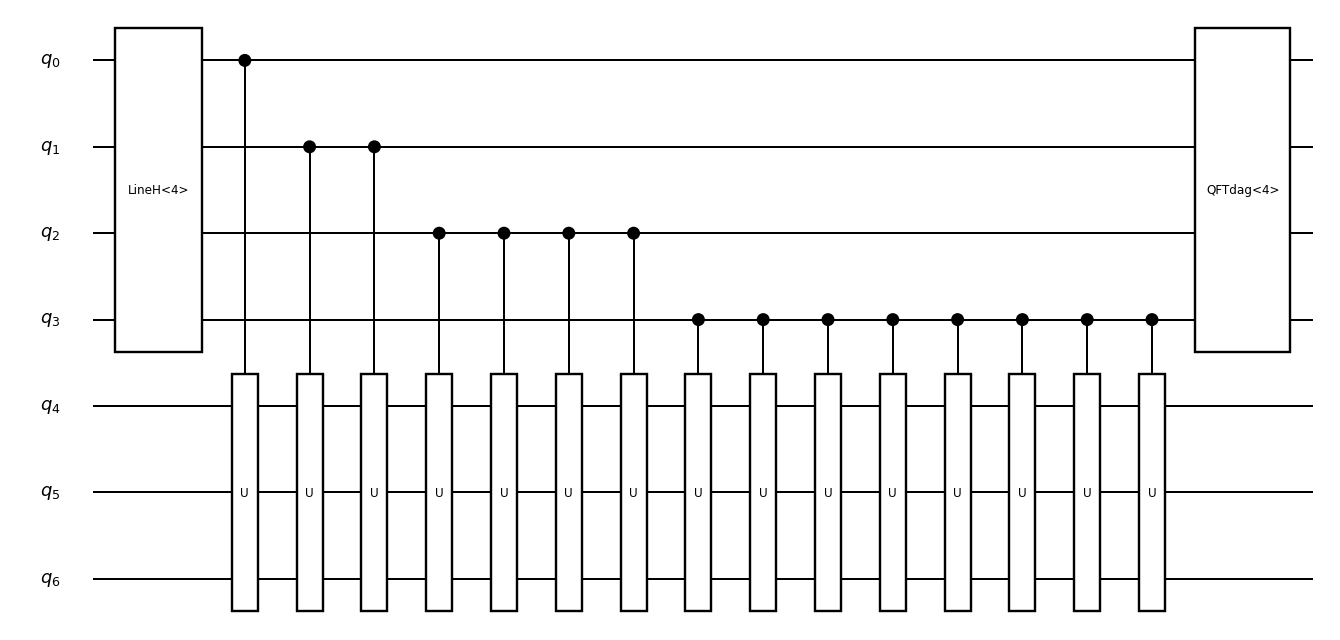

In [ ]:
draw(qpe_u_ops[1])

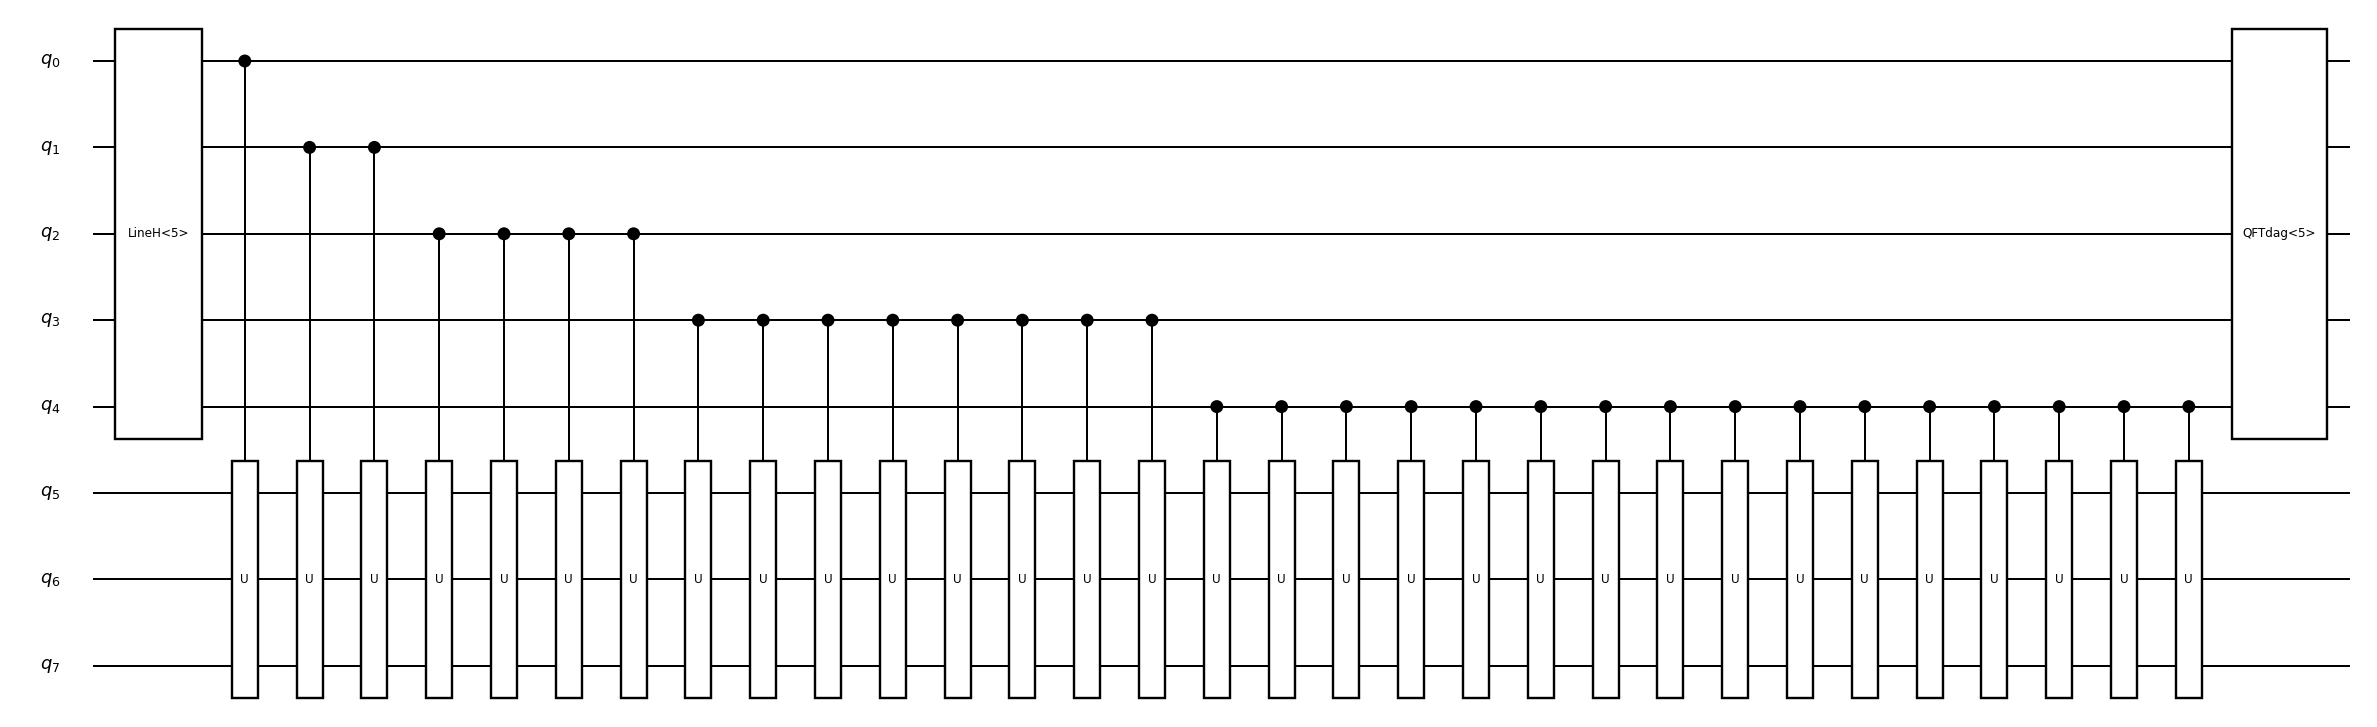

In [ ]:
draw(qpe_u_ops[2])

## Resource Estimation with qsub (QPE)


In [ ]:
# Compile the QPE circuits
from quri_parts.qsub.compile import compile
from quri_parts.qsub.evaluate import Evaluator
from quri_parts.qsub.eval import GateCountEvaluatorHooks, AuxQubitCountEvaluatorHooks
from quri_parts.qsub.primitive import AllBasicSet

required_qubit_list = []
for qpe_u_op in qpe_u_ops:
    compiled = compile(qpe_u_op, AllBasicSet)

    aux_qubit_counter = Evaluator(AuxQubitCountEvaluatorHooks())
    aux_qubits = aux_qubit_counter.run(compiled)
    required_qubits = len(compiled.qubits) + aux_qubits
    required_qubit_list.append(required_qubits)
    print(f"required_qubits for this circuit: {required_qubits}")

    gate_counter = Evaluator(GateCountEvaluatorHooks(AllBasicSet))
    gate_count = gate_counter.run(compiled)
    print({k[1]: v for k, v in gate_count.items()})
    print()


required_qubits for this circuit: 6
{'H': 48, 'CNOT': 48, 'RZ': 48, 'SWAP': 1, 'Phase': 3}

required_qubits for this circuit: 7
{'H': 98, 'CNOT': 102, 'RZ': 102, 'SWAP': 2, 'Phase': 6}

required_qubits for this circuit: 8
{'H': 196, 'CNOT': 206, 'RZ': 206, 'SWAP': 2, 'Phase': 10}



## Resource Estimation with quration


Please install qret CLI (needed for compile, profile, and visualization of quration IR/ISA) via the following command


In [ ]:
# Install qret-cli-bundle
# %pip install git+https://github.com/QunaSys/quration-cli-bundle.git


In [ ]:
# QPE resource estimation
import quri_parts.qret.convert_qsub as converter

for i in range(len(qpe_u_ops)):
    qpe_module = converter.create_module_from_qsub_op(entry_op=qpe_u_ops[i])

    # Dump the converted quration IR to a JSON file
    qpe_module.dump(f"_assets/multiple_circuit_resource_estimation/qpe/qpe_ir_{i}.json")


In [ ]:
import json

def beautifyJSON(filename):
    with open(filename, "r") as f:
        data = json.load(f)
    with open(filename, "w") as f:
        json.dump(data, f, indent=4)

for i in range(len(qpe_u_ops)):
    beautifyJSON(f"_assets/multiple_circuit_resource_estimation/qpe/qpe_ir_{i}.json")

In [ ]:
%cat _assets/multiple_circuit_resource_estimation/qpe/qpe_ir_0.json

{
    "metadata": {
        "format": "IR",
        "schema_version": "0.1",
        "qret_version": "1.0.1",
        "created_at": "2026-04-14T14:08:50"
    },
    "name": "__qsub____default__.QPE<3, __default__.U>",
    "circuit_list": [
        {
            "name": "main",
            "entry_point": "entry",
            "bb_list": [
                {
                    "name": "entry",
                    "inst_list": [
                        {
                            "opcode": "Call",
                            "callee": "__default__.QPE<3, __default__.U>",
                            "operate": [
                                0,
                                1,
                                2,
                                3,
                                4,
                                5
                            ],
                            "input": [],
                            "output": []
                        },
                        {
        

In [ ]:
%cat _assets/multiple_circuit_resource_estimation/qpe/qpe_ir_1.json

{
    "metadata": {
        "format": "IR",
        "schema_version": "0.1",
        "qret_version": "1.0.1",
        "created_at": "2026-04-14T14:08:50"
    },
    "name": "__qsub____default__.QPE<4, __default__.U>",
    "circuit_list": [
        {
            "name": "main",
            "entry_point": "entry",
            "bb_list": [
                {
                    "name": "entry",
                    "inst_list": [
                        {
                            "opcode": "Call",
                            "callee": "__default__.QPE<4, __default__.U>",
                            "operate": [
                                0,
                                1,
                                2,
                                3,
                                4,
                                5,
                                6
                            ],
                            "input": [],
                            "output": []
                        },

In [ ]:
%cat _assets/multiple_circuit_resource_estimation/qpe/qpe_ir_2.json

{
    "metadata": {
        "format": "IR",
        "schema_version": "0.1",
        "qret_version": "1.0.1",
        "created_at": "2026-04-14T14:08:50"
    },
    "name": "__qsub____default__.QPE<5, __default__.U>",
    "circuit_list": [
        {
            "name": "main",
            "entry_point": "entry",
            "bb_list": [
                {
                    "name": "entry",
                    "inst_list": [
                        {
                            "opcode": "Call",
                            "callee": "__default__.QPE<5, __default__.U>",
                            "operate": [
                                0,
                                1,
                                2,
                                3,
                                4,
                                5,
                                6,
                                7
                            ],
                            "input": [],
                            "out

## Topology File Generation


In [ ]:
import quri_parts.qret.topology_utils
for i in range(len(qpe_u_ops)):
    quri_parts.qret.topology_utils.write_generated_topology(f"_assets/multiple_circuit_resource_estimation/qpe/topology_for_qpe_{i}.yaml", required_qubit_list[i])

In [ ]:
%%sh
for i in 0 1 2; do
    cat _assets/multiple_circuit_resource_estimation/qpe/topology_for_qpe_${i}.yaml
    echo "-----------------------------"
done

grids:
  - type: plane
    coord: [7, 5, 0]
    magic_factory:
      - symbol: 0
        coord: [0, 0]
      - symbol: 1
        coord: [2, 0]
      - symbol: 2
        coord: [4, 0]
      - symbol: 3
        coord: [6, 0]
-----------------------------
grids:
  - type: plane
    coord: [7, 5, 0]
    magic_factory:
      - symbol: 0
        coord: [0, 0]
      - symbol: 1
        coord: [2, 0]
      - symbol: 2
        coord: [4, 0]
      - symbol: 3


        coord: [6, 0]
-----------------------------
grids:
  - type: plane
    coord: [7, 5, 0]
    magic_factory:
      - symbol: 0
        coord: [0, 0]
      - symbol: 1
        coord: [2, 0]
      - symbol: 2
        coord: [4, 0]
      - symbol: 3
        coord: [6, 0]
-----------------------------


## Compile the quration IR to ISA

First confirm that qret CLI is in the PATH, then compile using the pipeline files.


In [ ]:
import qret_cli_bundle
qret_cli_bundle.ensure_qret_on_path()

In [ ]:
%%sh
for i in 0 1 2; do
    cat _assets/multiple_circuit_resource_estimation/qpe/qpe_pipeline_${i}.yaml
    echo "-----------------------------"
done

source: IR
input: _assets/multiple_circuit_resource_estimation/qpe/qpe_ir_0.json
function: main
target: SC_LS_FIXED_V0
output: _assets/multiple_circuit_resource_estimation/qpe/compiled_qpe_0.json
sc_ls_fixed_v0_topology: _assets/multiple_circuit_resource_estimation/qpe/topology_for_qpe_0.yaml
sc_ls_fixed_v0_machine_type: Dim2
sc_ls_fixed_v0_magic_generation_period: 15
sc_ls_fixed_v0_maximum_magic_state_stock: 10000
sc_ls_fixed_v0_entanglement_generation_period: 100
sc_ls_fixed_v0_maximum_entangled_state_stock: 10
sc_ls_fixed_v0_reaction_time: 1
sc_ls_fixed_v0_drop_rate: 0.1
sc_ls_fixed_v0_code_cycle_time_sec: 0.00000001
sc_ls_fixed_v0_physical_error_rate: 0.01
sc_ls_fixed_v0_allowed_failure_prob: 0.01
sc_ls_fixed_v0_pass:
  - sc_ls_fixed_v0::init_compile_info
  - sc_ls_fixed_v0::mapping
  - sc_ls_fixed_v0::routing
-----------------------------
source: IR
input: _assets/multiple_circuit_resource_estimation/qpe/qpe_ir_1.json
function: main
target: SC_LS_FIXED_V0
output: _assets/multiple_

In [ ]:
%%sh
for i in 0 1 2; do
    qret compile --pipeline _assets/multiple_circuit_resource_estimation/qpe/qpe_pipeline_${i}.yaml
done

# This takes about 1 minute


Profile the generated ISA files


In [ ]:
%%sh
# Profile the compiled QPE files
for i in 0 1 2; do
    qret profile -i _assets/multiple_circuit_resource_estimation/qpe/compiled_qpe_${i}.json  -o _assets/multiple_circuit_resource_estimation/qpe/profiled_qpe_${i}.json
done


## Viewing Profiling Results with the Quration Visualizer


### Computational Process Visualizer

Visualizes the **execution trace (computational process)** of a quantum program beat by beat (timestep by timestep) in an animated fashion.

Launch it below, then load one of the compiled ISA files (`_assets/multiple_circuit_resource_estimation/qpe/compiled_qpe_0.json`, `compiled_qpe_1.json`, or `compiled_qpe_2.json`) from the Web UI. The visualizer shows nothing until a file is loaded.


In [ ]:
qret_cli_bundle.visualize_computational_process()

### Compile Info Visualizer

Displays and compares the post-compilation profile metrics across multiple profiles at once.

Launch it below and load all three profile files (`_assets/multiple_circuit_resource_estimation/qpe/profiled_qpe_0.json`, `profiled_qpe_1.json`, `profiled_qpe_2.json`) from the Web UI. With the three loaded together you can read off how each metric scales with the number of phase-readout qubits, for example `num_physical_qubits`, `magic_state_consumption_count`, and `execution_time_sec` all grow as precision increases. See the metric tables in the [basic tutorial](basic_resource_estimation.ipynb) for what each field means.


In [ ]:
qret_cli_bundle.visualize_compile_info()

![image.png](_assets/multiple_circuit_resource_estimation/image.png)